# VectoArena Suspicious Player Detection

Notebook này xây dựng pipeline phát hiện hành vi người chơi đáng nghi trong **VectoArena** bằng học không giám sát, sau đó dùng pseudo-label để huấn luyện model dự đoán người chơi mới.

Dataset hiện tại là synthetic 10k dòng, được thiết kế theo các trường phù hợp với server VectoArena: combat, movement, rule violations, match context và telemetry sau trận.

# 1. Giới thiệu đề tài

VectoArena đã có rule anti-cheat ở server như clamp tốc độ di chuyển, kiểm tra fire-rate, kiểm tra khoảng cách hit và khoảng cách nhặt item. Notebook này bổ sung lớp học máy để phát hiện mẫu hành vi bất thường sau trận.

Kết quả được diễn giải là **Normal/Suspicious**, không khẳng định chắc chắn người chơi gian lận.

# 2. Import thư viện

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
EPSILON = 1e-6

# 3. Đọc dữ liệu và kiểm tra tổng quan

In [2]:
BASE_DIR = Path.cwd()
DATA_FILENAME = 'vectoarena_anticheat_synthetic_10k.csv'
DATA_PATH = None

for candidate_base in [BASE_DIR, *BASE_DIR.parents]:
    candidates = [
        candidate_base / 'data' / DATA_FILENAME,
        candidate_base / 'ml' / 'data' / DATA_FILENAME,
        candidate_base / 'VectoArena_Server' / 'ml' / 'data' / DATA_FILENAME,
    ]
    for candidate in candidates:
        if candidate.exists():
            DATA_PATH = candidate
            break
    if DATA_PATH is not None:
        break

if DATA_PATH is None:
    raise FileNotFoundError(f'Không tìm thấy dataset: {DATA_PATH}')

ML_DIR = DATA_PATH.parent.parent

df = pd.read_csv(DATA_PATH)

print('Dataset path:', DATA_PATH)
print('Loaded dataset shape:', df.shape)
print('Memory usage:', f'{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
display(df.head())

info_df = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing': df.isna().sum().values,
    'missing_pct': (df.isna().mean().values * 100).round(2),
    'unique': df.nunique(dropna=False).values,
})
display(info_df)
display(df.describe(include='number').T.round(3))
display(df.describe(include=['object']).T)

Dataset path: D:\Project\Unity\DACN1\VectoArena_Server\ml\data\vectoarena_anticheat_synthetic_10k.csv
Loaded dataset shape: (10000, 46)
Memory usage: 7.95 MB


,synthetic_id,match_id,participant_id,user_id,mode,maxPlayers,matchDurationSeconds,survivedSeconds,placement,isWinner,...,damagePerMinute,damagePerKill,allowedMaxHitDistance,allowedMaxItemPickupDistance,allowedMoveSpeedWithGrace,behaviorProfile,pseudoSuspiciousLabel,pseudoLabelName,suspiciousScoreSeed,reasonCodes
0,syn_00000,match_00000,participant_00000,user_0000,BATTLE,4,31,26,1,1,...,80.76923,35.0,60,3,4.725,normal,0,Normal,0.19824,HIGH_KILLS_PER_MINUTE
1,syn_00001,match_00000,participant_00001,user_0001,BATTLE,4,280,182,3,0,...,41.86813,127.0,60,3,4.725,normal,0,Normal,0.00000,BASELINE
2,syn_00002,match_00000,participant_00002,user_0002,BATTLE,4,81,8,1,1,...,525.00000,35.0,60,3,4.725,normal,0,Normal,0.42943,HIGH_DAMAGE_PER_MINUTE|HIGH_KILLS_PER_MINUTE
3,syn_00003,match_00000,participant_00003,user_0003,BATTLE,4,111,43,2,0,...,36.27907,26.0,60,3,4.725,normal,0,Normal,0.00000,BASELINE
4,syn_00004,match_00001,participant_00004,user_0004,BATTLE,4,70,21,4,0,...,405.71429,35.5,60,3,4.725,normal,0,Normal,0.43633,HIGH_HIT_RATE|HIGH_DAMAGE_PER_MINUTE|HIGH_KILL...


,column,dtype,missing,missing_pct,unique
0,synthetic_id,str,0,0.0,10000
1,match_id,str,0,0.0,2500
2,participant_id,str,0,0.0,10000
3,user_id,str,0,0.0,2500
4,mode,str,0,0.0,2
5,maxPlayers,int64,0,0.0,1
6,matchDurationSeconds,int64,0,0.0,343
7,survivedSeconds,int64,0,0.0,302
8,placement,int64,0,0.0,4
9,isWinner,int64,0,0.0,2


,count,mean,std,min,25%,50%,75%,max
maxPlayers,10000.0,4.000,0.000,4.000,4.000,4.000,4.000,4.000
matchDurationSeconds,10000.0,124.779,83.441,18.000,57.000,102.000,180.000,360.000
survivedSeconds,10000.0,58.578,54.545,8.000,18.000,40.000,82.000,352.000
placement,10000.0,2.403,1.125,1.000,1.000,2.000,3.000,4.000
isWinner,10000.0,0.286,0.452,0.000,0.000,0.000,1.000,1.000
weaponDamage,10000.0,16.760,14.849,0.000,8.000,12.000,25.000,60.000
weaponFireRatePerSecond,10000.0,5.129,5.123,0.000,1.000,1.500,9.000,20.000
kills,10000.0,1.442,2.477,0.000,0.000,0.000,2.000,18.000
deaths,10000.0,0.714,0.452,0.000,0.000,1.000,1.000,1.000
damageDealt,10000.0,81.376,114.233,0.000,15.000,35.000,105.000,1644.000


,count,unique,top,freq
synthetic_id,10000,10000,syn_00000,1
match_id,10000,2500,match_00000,4
participant_id,10000,10000,participant_00000,1
user_id,10000,2500,user_0000,4
mode,10000,2,BATTLE,8212
primaryWeapon,10000,12,Shotgun,1836
behaviorProfile,10000,4,normal,8532
pseudoLabelName,10000,2,Normal,9323
reasonCodes,10000,40,BASELINE,5301


# 4. EDA - Khám phá dữ liệu

Phân bố nhãn synthetic:


,count
pseudoLabelName,
Normal,9323
Suspicious,677


Phân bố behaviorProfile:


,count
behaviorProfile,
normal,8532
high_skill,860
suspicious_soft,449
suspicious_hard,159


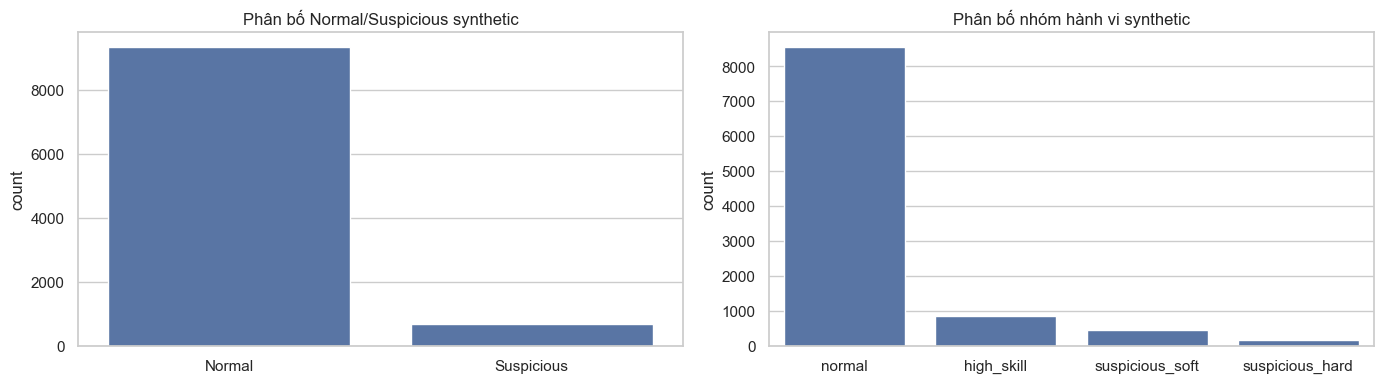

In [3]:
print('Phân bố nhãn synthetic:')
display(df['pseudoLabelName'].value_counts().to_frame('count'))

print('Phân bố behaviorProfile:')
display(df['behaviorProfile'].value_counts().to_frame('count'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=df, x='pseudoLabelName', order=['Normal', 'Suspicious'], ax=axes[0])
axes[0].set_title('Phân bố Normal/Suspicious synthetic')
axes[0].set_xlabel('')
sns.countplot(data=df, x='behaviorProfile', order=df['behaviorProfile'].value_counts().index, ax=axes[1])
axes[1].set_title('Phân bố nhóm hành vi synthetic')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

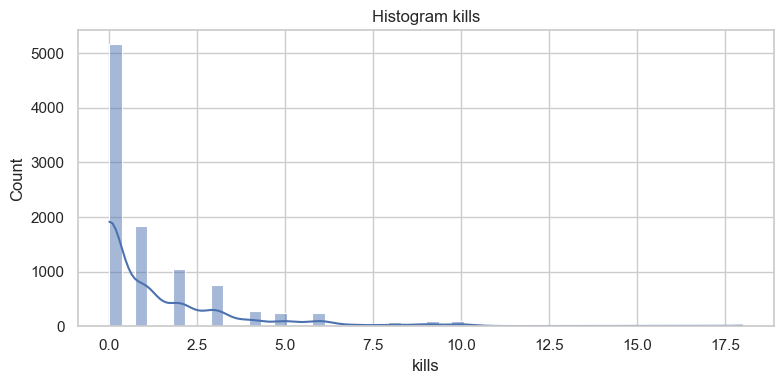

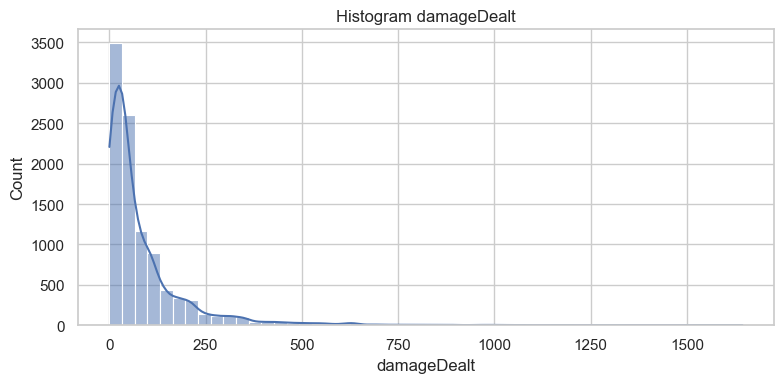

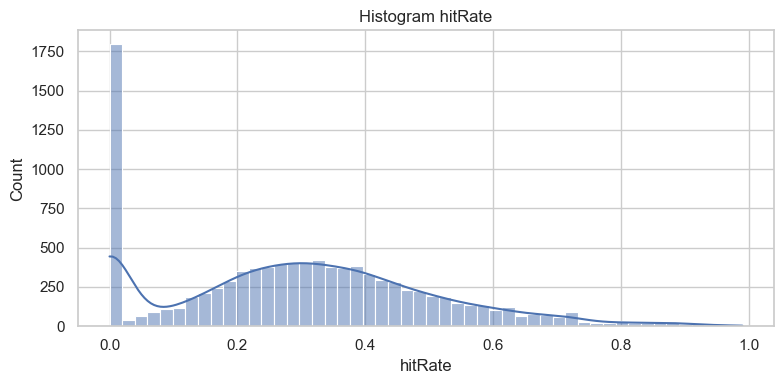

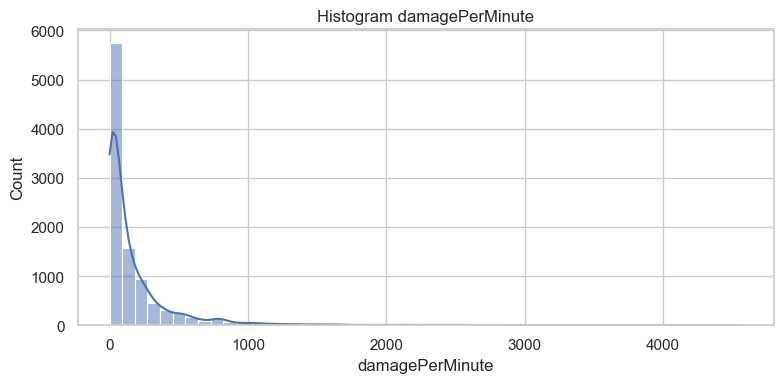

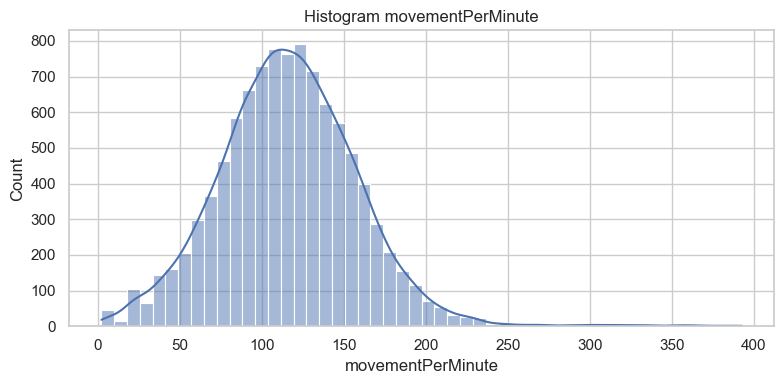

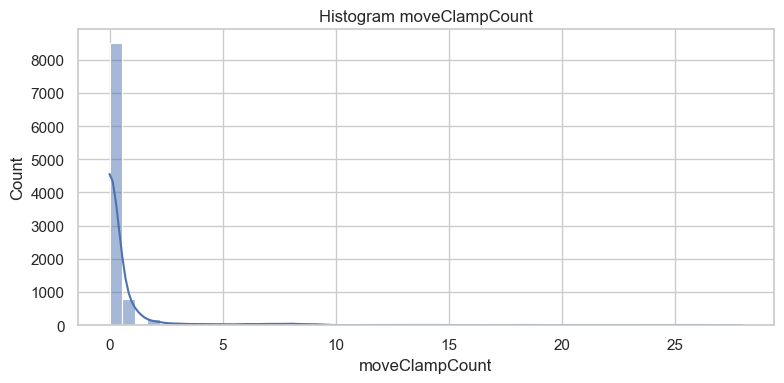

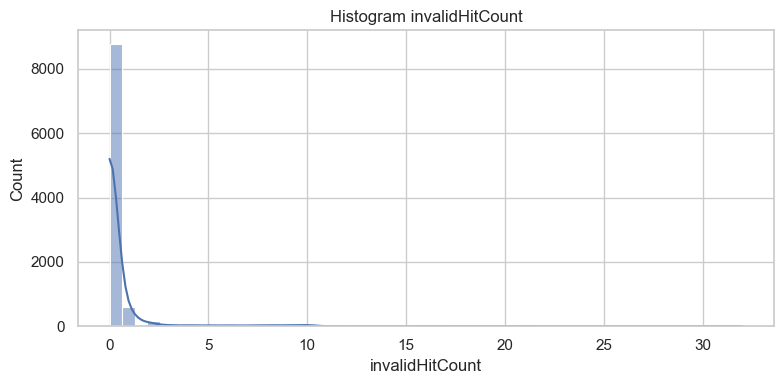

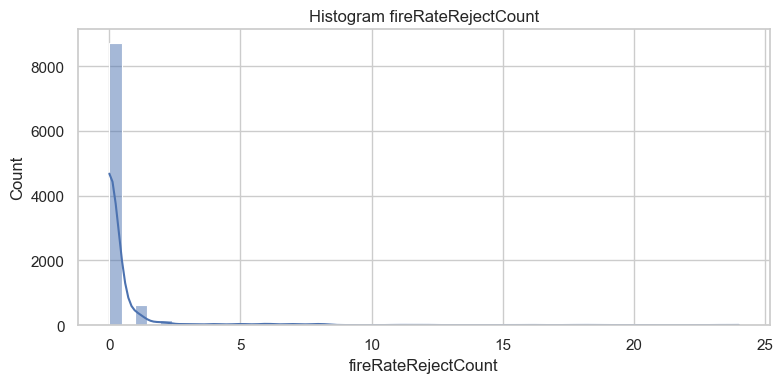

In [4]:
hist_cols = ['kills', 'damageDealt', 'hitRate', 'damagePerMinute', 'movementPerMinute', 'moveClampCount', 'invalidHitCount', 'fireRateRejectCount']

for col in hist_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Histogram {col}')
    plt.tight_layout()
    plt.show()

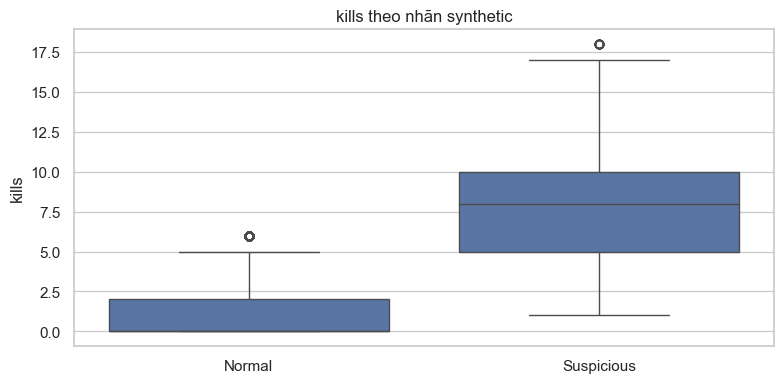

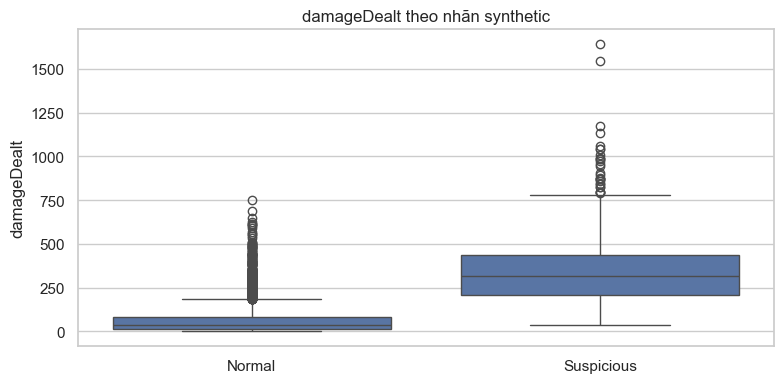

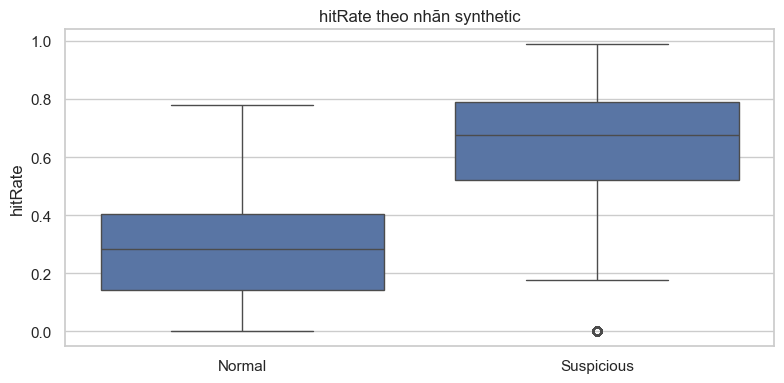

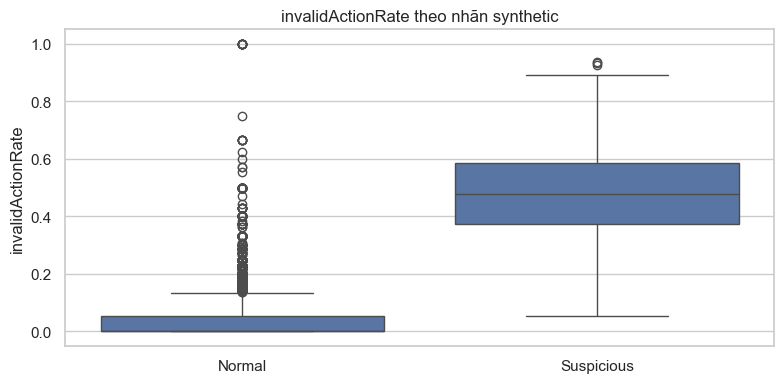

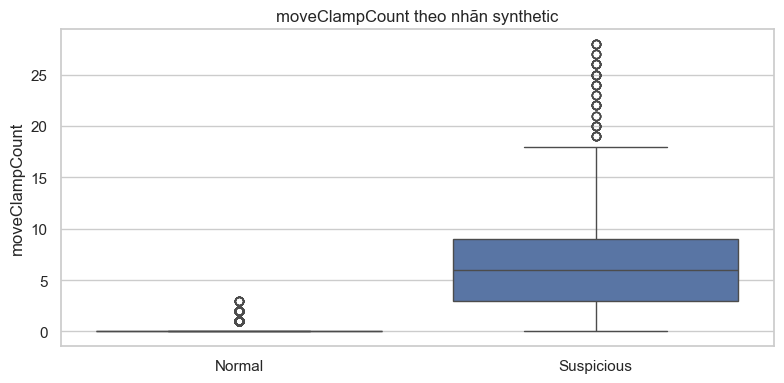

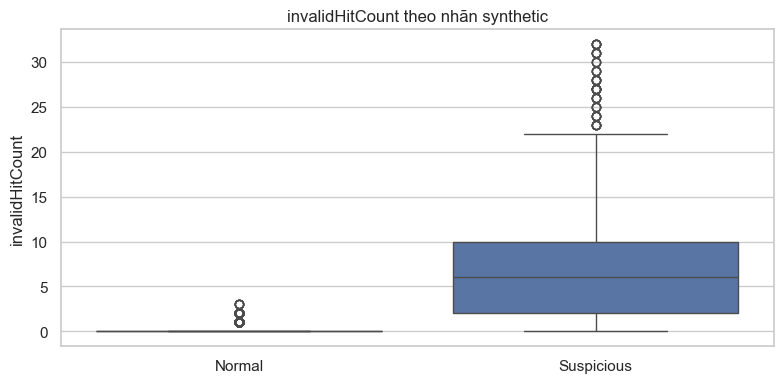

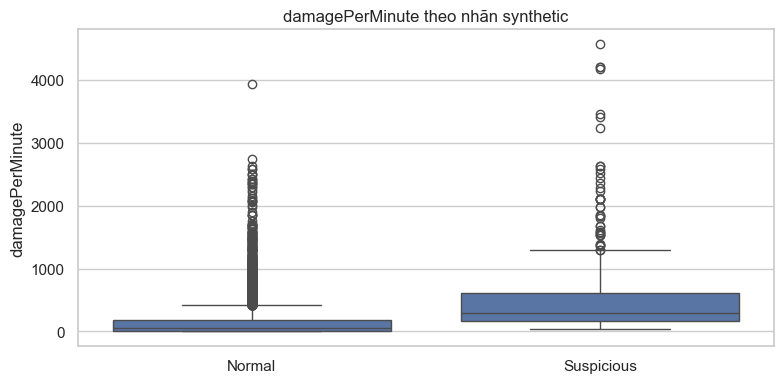

In [5]:
box_cols = ['kills', 'damageDealt', 'hitRate', 'invalidActionRate', 'moveClampCount', 'invalidHitCount', 'damagePerMinute']

for col in box_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='pseudoLabelName', y=col, order=['Normal', 'Suspicious'])
    plt.title(f'{col} theo nhãn synthetic')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()

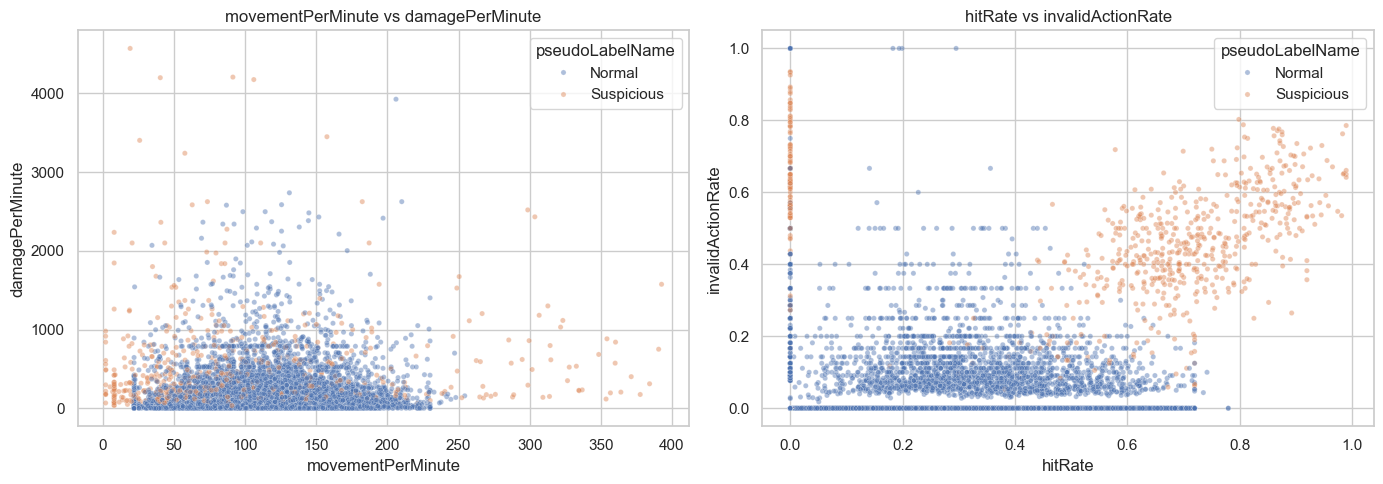

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='movementPerMinute', y='damagePerMinute', hue='pseudoLabelName', alpha=0.45, s=14, ax=axes[0])
axes[0].set_title('movementPerMinute vs damagePerMinute')
sns.scatterplot(data=df, x='hitRate', y='invalidActionRate', hue='pseudoLabelName', alpha=0.45, s=14, ax=axes[1])
axes[1].set_title('hitRate vs invalidActionRate')
plt.tight_layout()
plt.show()

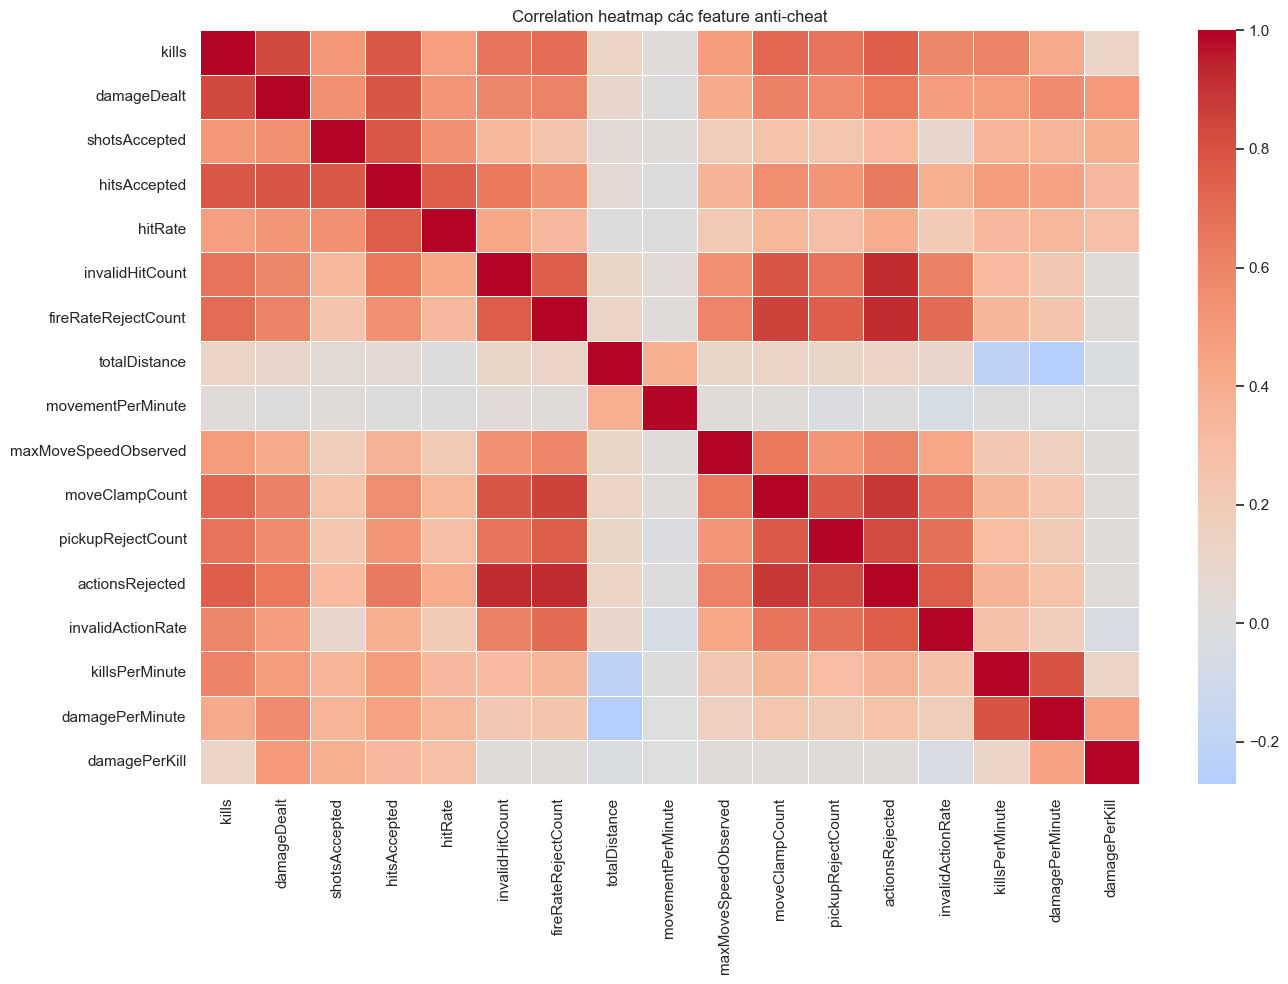

In [7]:
corr_cols = [
    'kills', 'damageDealt', 'shotsAccepted', 'hitsAccepted', 'hitRate',
    'invalidHitCount', 'fireRateRejectCount', 'totalDistance', 'movementPerMinute',
    'maxMoveSpeedObserved', 'moveClampCount', 'pickupRejectCount', 'actionsRejected',
    'invalidActionRate', 'killsPerMinute', 'damagePerMinute', 'damagePerKill'
]
corr_cols = [col for col in corr_cols if col in df.columns]

plt.figure(figsize=(14, 10))
sns.heatmap(df[corr_cols].corr(), cmap='coolwarm', center=0, linewidths=0.4)
plt.title('Correlation heatmap các feature anti-cheat')
plt.tight_layout()
plt.show()

**Nhận xét EDA:** nhóm suspicious thường có `hitRate`, `damagePerMinute`, `invalidActionRate`, `moveClampCount`, `invalidHitCount` cao hơn. Người chơi giỏi có thể có combat cao nhưng ít vi phạm rule, vì vậy không nên chỉ dựa vào kills/damage để kết luận.

# 5. Làm sạch dữ liệu và Feature Engineering

In [8]:
df_clean = df.drop_duplicates().copy()
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()
df_clean = df_clean[df_clean['matchDurationSeconds'] > 0].copy()
df_clean['survivedSeconds'] = df_clean['survivedSeconds'].clip(lower=1)

model_df = df_clean.copy()
model_df['hitRate'] = np.where(model_df['shotsAccepted'] > 0, model_df['hitsAccepted'] / (model_df['shotsAccepted'] + EPSILON), 0)
model_df['movementPerMinute'] = model_df['totalDistance'] / (model_df['survivedSeconds'] / 60 + EPSILON)
model_df['killsPerMinute'] = model_df['kills'] / (model_df['survivedSeconds'] / 60 + EPSILON)
model_df['damagePerMinute'] = model_df['damageDealt'] / (model_df['survivedSeconds'] / 60 + EPSILON)
model_df['damagePerKill'] = np.where(model_df['kills'] > 0, model_df['damageDealt'] / (model_df['kills'] + EPSILON), 0)
model_df['actionsRejected'] = model_df['invalidHitCount'] + model_df['fireRateRejectCount'] + model_df['pickupRejectCount'] + model_df['meleeInvalidCount']
total_actions = model_df['shotsAccepted'] + model_df['pickupCount'] + model_df['meleeAttackCount'] + model_df['actionsRejected']
model_df['invalidActionRate'] = np.where(total_actions > 0, model_df['actionsRejected'] / (total_actions + EPSILON), 0)

categorical_cols = ['mode', 'primaryWeapon']
model_encoded = pd.get_dummies(model_df, columns=categorical_cols, prefix=categorical_cols, dtype=int)

selected_numeric_features = [
    # Match context needed to normalize short/long matches.
    'survivedSeconds',

    # Weapon context. These explain expected damage/fire-rate behavior without using match outcome columns.
    'weaponDamage',
    'weaponFireRatePerSecond',

    # Server-authoritative combat telemetry.
    'shotsAccepted',
    'hitsAccepted',
    'hitRate',
    'invalidHitCount',
    'fireRateRejectCount',

    # Server-authoritative movement telemetry.
    'movementPerMinute',
    'maxMoveSpeedObserved',
    'moveClampCount',
    'moveClampRate',

    # Interaction telemetry and normalized rejection signal.
    'pickupCount',
    'pickupRejectCount',
    'meleeAttackCount',
    'meleeInvalidCount',
    'invalidActionRate',

    # Performance rates, kept instead of raw match result columns.
    'killsPerMinute',
    'damagePerMinute',
    'damagePerKill',
]
categorical_feature_cols = [
    col for col in model_encoded.columns
    if col.startswith('mode_') or col.startswith('primaryWeapon_')
]
feature_cols = [col for col in selected_numeric_features + categorical_feature_cols if col in model_encoded.columns]

print('Shape sau làm sạch:', model_encoded.shape)
print('Số feature dùng để train:', len(feature_cols))
print(feature_cols)

Shape sau làm sạch: (10000, 58)
Số feature dùng để train: 34
['survivedSeconds', 'weaponDamage', 'weaponFireRatePerSecond', 'shotsAccepted', 'hitsAccepted', 'hitRate', 'invalidHitCount', 'fireRateRejectCount', 'movementPerMinute', 'maxMoveSpeedObserved', 'moveClampCount', 'moveClampRate', 'pickupCount', 'pickupRejectCount', 'meleeAttackCount', 'meleeInvalidCount', 'invalidActionRate', 'killsPerMinute', 'damagePerMinute', 'damagePerKill', 'mode_BATTLE', 'mode_PLAY_TO_AIRDROP', 'primaryWeapon_BlasterShotgun', 'primaryWeapon_BurstRifle', 'primaryWeapon_HunterSniper', 'primaryWeapon_Launcher', 'primaryWeapon_MachineGun', 'primaryWeapon_Minigun', 'primaryWeapon_Pistol', 'primaryWeapon_RebelRifle', 'primaryWeapon_Rifle', 'primaryWeapon_Shotgun', 'primaryWeapon_Sniper', 'primaryWeapon_Sword']


# 6. Sampling, Scaling và PCA

Explained variance ratio: [0.19396707 0.09023621]


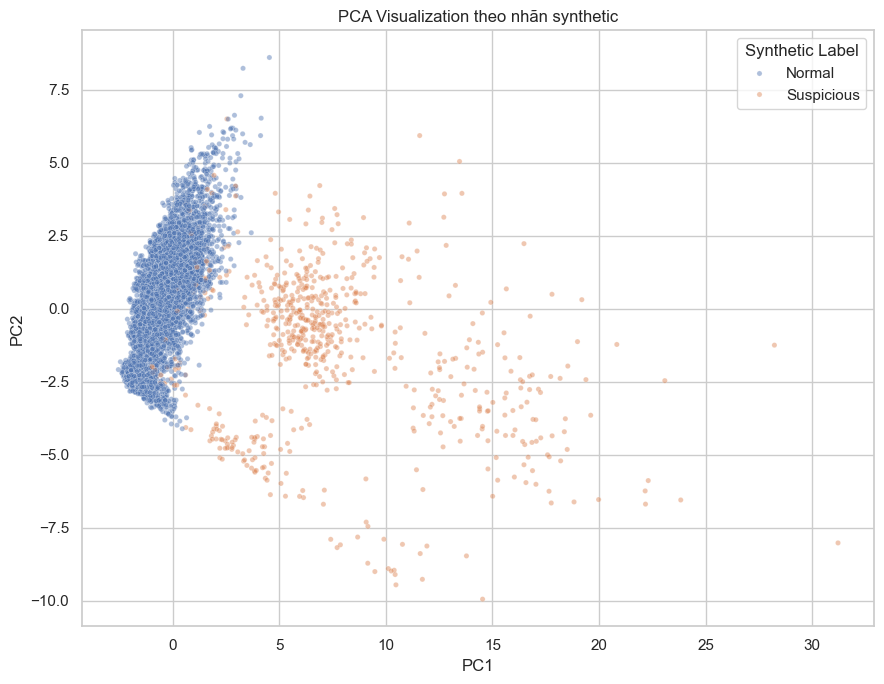

In [9]:
OUTPUT_DIR = ML_DIR / 'outputs'
MODELS_DIR = ML_DIR / 'models'
FIGURES_DIR = OUTPUT_DIR / 'figures'
REPORTS_DIR = OUTPUT_DIR / 'reports'

for path in [OUTPUT_DIR, MODELS_DIR, FIGURES_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

sample_model = model_encoded.sample(n=min(10000, len(model_encoded)), random_state=RANDOM_STATE).copy()
X_model = sample_model[feature_cols].copy()

scaler = StandardScaler()
X_model_scaled = scaler.fit_transform(X_model)

joblib.dump(scaler, MODELS_DIR / 'vectoarena_scaler.pkl')
joblib.dump(feature_cols, MODELS_DIR / 'vectoarena_feature_cols.pkl')

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_model_pca = pca.fit_transform(X_model_scaled)
print('Explained variance ratio:', pca.explained_variance_ratio_)

pca_df = pd.DataFrame({
    'PC1': X_model_pca[:, 0],
    'PC2': X_model_pca[:, 1],
    'Synthetic Label': sample_model['pseudoLabelName'].values,
    'Profile': sample_model['behaviorProfile'].values,
})

plt.figure(figsize=(9, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Synthetic Label', alpha=0.45, s=14)
plt.title('PCA Visualization theo nhãn synthetic')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_synthetic_label.png', dpi=150)
plt.show()

# 7. Model 1 - K-Means

Training KMeans k=2...


Training KMeans k=3...
Training KMeans k=4...


Training KMeans k=5...
Training KMeans k=6...


Training KMeans k=7...
Training KMeans k=8...


Training KMeans k=9...
Training KMeans k=10...


,K,Inertia,Silhouette
0,2,291966.384914,0.449213
1,3,269540.792379,0.086982
2,4,249989.227936,0.123515
3,5,236073.493128,0.144098
4,6,224772.270332,0.146946
5,7,213703.263010,0.160419
6,8,202461.710367,0.182245
7,9,193010.232901,0.208841
8,10,180798.256789,0.221733


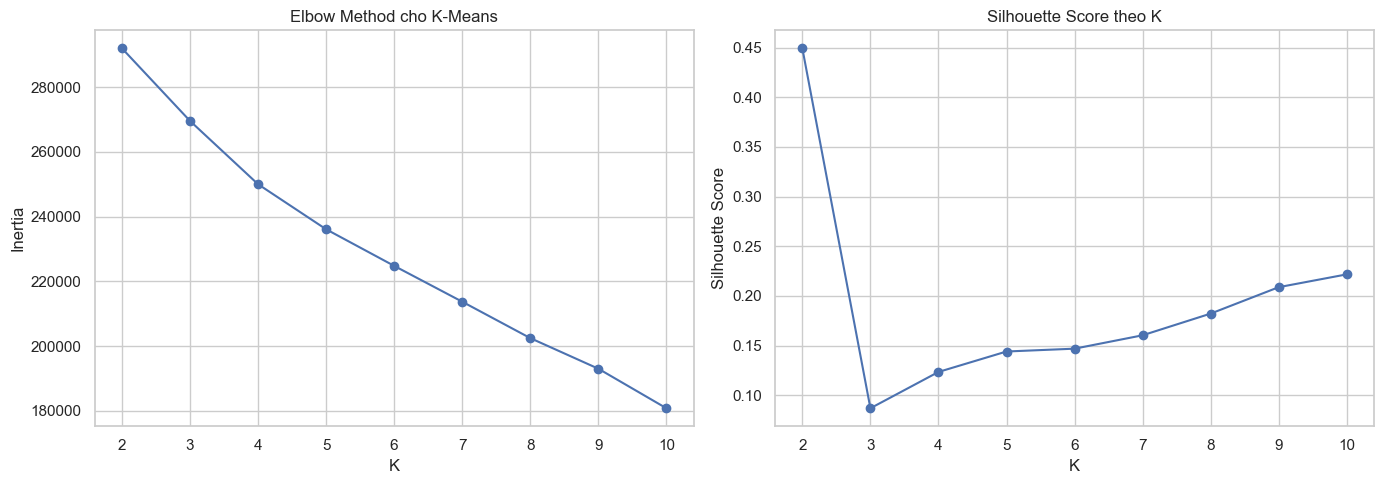

K được chọn: 2
Suspicious clusters: [1]


,suspicious_score
kmeans_cluster,
1,2.436173
0,-0.143426


,hitRate,damagePerMinute,killsPerMinute,invalidActionRate,moveClampCount,invalidHitCount,fireRateRejectCount,pseudoSuspiciousLabel
kmeans_cluster,,,,,,,,
0,0.256,150.910,2.319,0.044,0.136,0.101,0.107,0.013
1,0.741,520.752,12.129,0.513,9.106,8.763,7.631,1.000


['D:\\Project\\Unity\\DACN1\\VectoArena_Server\\ml\\models\\vectoarena_kmeans.pkl']

In [10]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []
rng = np.random.RandomState(RANDOM_STATE)
sil_idx = rng.choice(len(X_model_scaled), size=min(2000, len(X_model_scaled)), replace=False)

for k in k_values:
    print(f'Training KMeans k={k}...')
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels = km_tmp.fit_predict(X_model_scaled)
    inertias.append(km_tmp.inertia_)
    silhouette_scores.append(silhouette_score(X_model_scaled[sil_idx], labels[sil_idx]))

kmeans_eval = pd.DataFrame({'K': list(k_values), 'Inertia': inertias, 'Silhouette': silhouette_scores})
display(kmeans_eval)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(kmeans_eval['K'], kmeans_eval['Inertia'], marker='o')
axes[0].set_title('Elbow Method cho K-Means')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[1].plot(kmeans_eval['K'], kmeans_eval['Silhouette'], marker='o')
axes[1].set_title('Silhouette Score theo K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kmeans_eval.png', dpi=150)
plt.show()

best_k = int(kmeans_eval.loc[kmeans_eval['Silhouette'].idxmax(), 'K'])
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20, max_iter=300)
sample_model['kmeans_cluster'] = kmeans.fit_predict(X_model_scaled)

suspicious_indicators = ['hitRate', 'damagePerMinute', 'killsPerMinute', 'invalidActionRate', 'moveClampCount', 'invalidHitCount', 'fireRateRejectCount']
indicator_profile = sample_model.groupby('kmeans_cluster')[suspicious_indicators].mean()
cluster_suspicious_score = ((indicator_profile - sample_model[suspicious_indicators].mean()) / sample_model[suspicious_indicators].std().replace(0, 1)).mean(axis=1)
suspicious_clusters = cluster_suspicious_score.sort_values(ascending=False).head(max(1, int(np.ceil(best_k * 0.25)))).index.tolist()
sample_model['kmeans_suspicious'] = sample_model['kmeans_cluster'].isin(suspicious_clusters)

print('K được chọn:', best_k)
print('Suspicious clusters:', suspicious_clusters)
display(cluster_suspicious_score.sort_values(ascending=False).to_frame('suspicious_score'))
display(sample_model.groupby('kmeans_cluster')[suspicious_indicators + ['pseudoSuspiciousLabel']].mean().round(3))

joblib.dump(kmeans, MODELS_DIR / 'vectoarena_kmeans.pkl')

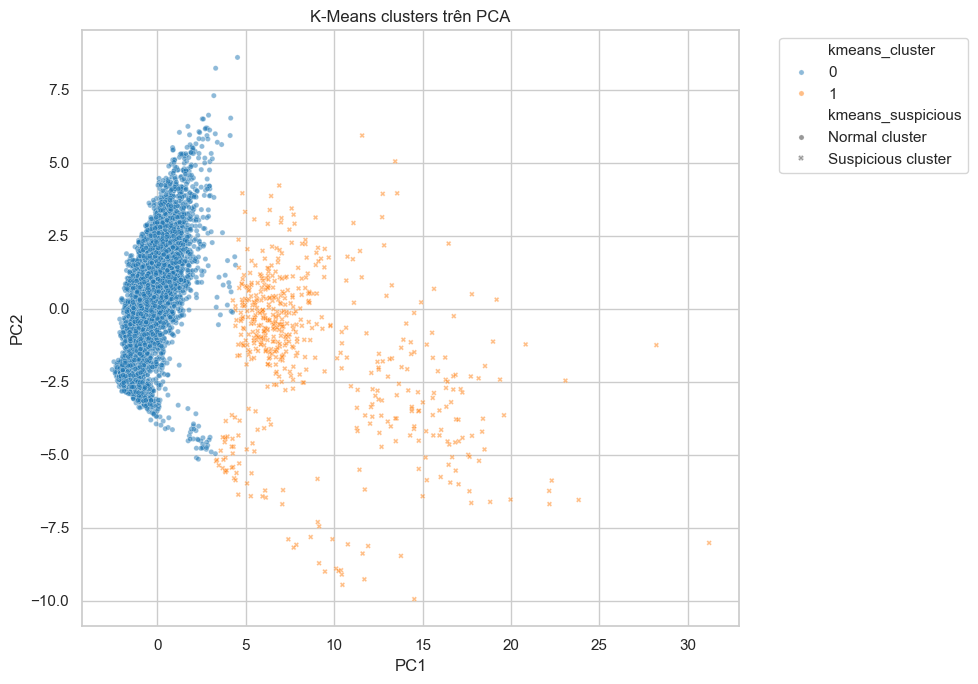

In [11]:
kmeans_plot_df = pd.DataFrame({
    'PC1': X_model_pca[:, 0],
    'PC2': X_model_pca[:, 1],
    'kmeans_cluster': sample_model['kmeans_cluster'].astype(str).values,
    'kmeans_suspicious': sample_model['kmeans_suspicious'].map({False: 'Normal cluster', True: 'Suspicious cluster'}).values,
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=kmeans_plot_df, x='PC1', y='PC2', hue='kmeans_cluster', style='kmeans_suspicious', s=14, alpha=0.5, palette='tab10')
plt.title('K-Means clusters trên PCA')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kmeans_clusters_pca.png', dpi=150)
plt.show()

# 8. Model 2 - Mean Shift

In [12]:
bandwidth = estimate_bandwidth(X_model_scaled, quantile=0.2, n_samples=min(1500, len(X_model_scaled)), random_state=RANDOM_STATE)
bandwidth = max(float(bandwidth), EPSILON)
print('Bandwidth:', bandwidth)

meanshift = MeanShift(bandwidth=bandwidth, max_iter=120, bin_seeding=True)
ms_fit_size = min(2500, len(X_model_scaled))
ms_fit_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_model_scaled), size=ms_fit_size, replace=False)
meanshift.fit(X_model_scaled[ms_fit_idx])
sample_model['meanshift_cluster'] = meanshift.predict(X_model_scaled)
n_ms_clusters = sample_model['meanshift_cluster'].nunique()

ms_indicator_profile = sample_model.groupby('meanshift_cluster')[suspicious_indicators].mean()
meanshift_suspicious_score = ((ms_indicator_profile - sample_model[suspicious_indicators].mean()) / sample_model[suspicious_indicators].std().replace(0, 1)).mean(axis=1)
meanshift_suspicious_clusters = meanshift_suspicious_score.sort_values(ascending=False).head(max(1, int(np.ceil(n_ms_clusters * 0.10)))).index.tolist()
sample_model['meanshift_suspicious'] = sample_model['meanshift_cluster'].isin(meanshift_suspicious_clusters)

print('Số cluster Mean Shift:', n_ms_clusters)
print('Suspicious clusters:', meanshift_suspicious_clusters)
print('Tỷ lệ suspicious:', sample_model['meanshift_suspicious'].mean())
display(sample_model['meanshift_cluster'].value_counts().sort_index().to_frame('count'))
display(meanshift_suspicious_score.sort_values(ascending=False).to_frame('suspicious_score').head(20))

joblib.dump(meanshift, MODELS_DIR / 'vectoarena_meanshift.pkl')

Bandwidth: 6.567139136143367
Số cluster Mean Shift: 4
Suspicious clusters: [3]
Tỷ lệ suspicious: 0.0143


,count
meanshift_cluster,
0,9250
1,298
2,309
3,143


,suspicious_score
meanshift_cluster,
3,4.106638
2,0.093704
0,-0.063504
1,-0.096605


['D:\\Project\\Unity\\DACN1\\VectoArena_Server\\ml\\models\\vectoarena_meanshift.pkl']

# 9. Model 3 - DBSCAN

Training DBSCAN eps=1.5...


eps=1.5, clusters=18, noise=6433, outlier_ratio=0.6433
Training DBSCAN eps=2.0...
eps=2.0, clusters=24, noise=2798, outlier_ratio=0.2798
Training DBSCAN eps=2.5...


eps=2.5, clusters=24, noise=1292, outlier_ratio=0.1292
Training DBSCAN eps=3.0...


eps=3.0, clusters=24, noise=838, outlier_ratio=0.0838
Training DBSCAN eps=3.5...
eps=3.5, clusters=24, noise=654, outlier_ratio=0.0654
Training DBSCAN eps=4.0...


eps=4.0, clusters=15, noise=541, outlier_ratio=0.0541


,eps,n_clusters,n_noise,outlier_ratio
0,1.5,18,6433,0.6433
1,2.0,24,2798,0.2798
2,2.5,24,1292,0.1292
3,3.0,24,838,0.0838
4,3.5,24,654,0.0654
5,4.0,15,541,0.0541


eps được chọn: 3.5
Outlier ratio cuối: 0.0654


,count
dbscan_label,
-1,654
0,47
1,573
2,1345
3,297
4,1410
5,323
6,120
7,471


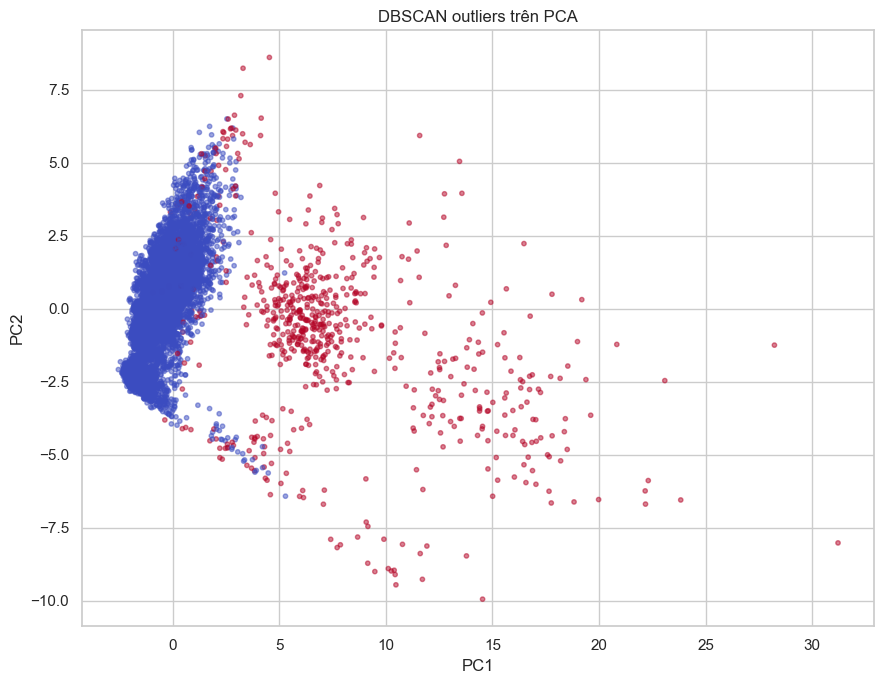

['D:\\Project\\Unity\\DACN1\\VectoArena_Server\\ml\\models\\vectoarena_dbscan.pkl']

In [13]:
eps_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
min_samples = 10
dbscan_results = []

for eps in eps_values:
    print(f'Training DBSCAN eps={eps}...')
    db_tmp = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db_tmp.fit_predict(X_model_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    outlier_ratio = n_noise / len(labels)
    dbscan_results.append({'eps': eps, 'n_clusters': n_clusters, 'n_noise': n_noise, 'outlier_ratio': outlier_ratio})
    print(f'eps={eps}, clusters={n_clusters}, noise={n_noise}, outlier_ratio={outlier_ratio:.4f}')

dbscan_eval = pd.DataFrame(dbscan_results)
display(dbscan_eval)

candidate = dbscan_eval[(dbscan_eval['outlier_ratio'] >= 0.03) & (dbscan_eval['outlier_ratio'] <= 0.15)].copy()
chosen_eps = float(candidate.iloc[(candidate['outlier_ratio'] - 0.06).abs().argsort()].iloc[0]['eps']) if len(candidate) > 0 else float(dbscan_eval.iloc[(dbscan_eval['outlier_ratio'] - 0.06).abs().argsort()].iloc[0]['eps'])

dbscan = DBSCAN(eps=chosen_eps, min_samples=min_samples)
sample_model['dbscan_label'] = dbscan.fit_predict(X_model_scaled)
sample_model['dbscan_suspicious'] = sample_model['dbscan_label'] == -1

print('eps được chọn:', chosen_eps)
print('Outlier ratio cuối:', sample_model['dbscan_suspicious'].mean())
display(sample_model['dbscan_label'].value_counts().sort_index().to_frame('count'))

plt.figure(figsize=(9, 7))
plt.scatter(X_model_pca[:, 0], X_model_pca[:, 1], c=sample_model['dbscan_suspicious'].map({False: 0, True: 1}), cmap='coolwarm', s=10, alpha=0.5)
plt.title('DBSCAN outliers trên PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dbscan_outliers.png', dpi=150)
plt.show()

joblib.dump(dbscan, MODELS_DIR / 'vectoarena_dbscan.pkl')

# 10. Model 4 - Gaussian Mixture Model

Training GMM n_components=2...
Training GMM n_components=3...
Training GMM n_components=4...
Training GMM n_components=5...


Training GMM n_components=6...
Training GMM n_components=7...
Training GMM n_components=8...
Training GMM n_components=9...
Training GMM n_components=10...


,n_components,BIC,AIC
0,2,608677.107350,607689.290719
1,3,139243.689565,137758.359448
2,4,-62802.084527,-64784.928129
3,5,-267524.673519,-270005.030607
4,6,-400276.779898,-403254.650472
5,7,-735691.231337,-739166.615396
6,8,-833236.628951,-837209.526496
7,9,-916463.635150,-920934.046181
8,10,-934602.047128,-939569.971644


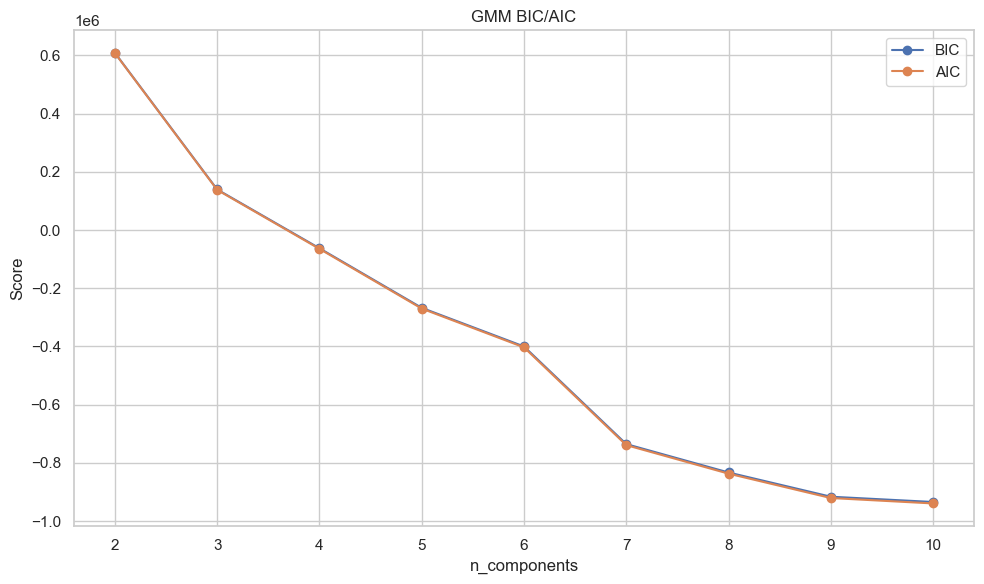

n_components được chọn: 10
GMM threshold 5% thấp nhất: -24.76219982766412
Tỷ lệ suspicious theo GMM: 0.05


['D:\\Project\\Unity\\DACN1\\VectoArena_Server\\ml\\models\\vectoarena_gmm.pkl']

In [14]:
gmm_results = []

for n in range(2, 11):
    print(f'Training GMM n_components={n}...')
    gmm_tmp = GaussianMixture(n_components=n, covariance_type='diag', random_state=RANDOM_STATE, max_iter=200, reg_covar=1e-6)
    gmm_tmp.fit(X_model_scaled)
    gmm_results.append({'n_components': n, 'BIC': gmm_tmp.bic(X_model_scaled), 'AIC': gmm_tmp.aic(X_model_scaled)})

gmm_eval = pd.DataFrame(gmm_results)
display(gmm_eval)

plt.figure()
plt.plot(gmm_eval['n_components'], gmm_eval['BIC'], marker='o', label='BIC')
plt.plot(gmm_eval['n_components'], gmm_eval['AIC'], marker='o', label='AIC')
plt.title('GMM BIC/AIC')
plt.xlabel('n_components')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gmm_bic_aic.png', dpi=150)
plt.show()

best_n_components = int(gmm_eval.loc[gmm_eval['BIC'].idxmin(), 'n_components'])
gmm = GaussianMixture(n_components=best_n_components, covariance_type='diag', random_state=RANDOM_STATE, max_iter=300, reg_covar=1e-6)
sample_model['gmm_cluster'] = gmm.fit_predict(X_model_scaled)
sample_model['gmm_score'] = gmm.score_samples(X_model_scaled)
gmm_threshold = np.percentile(sample_model['gmm_score'], 5)
sample_model['gmm_suspicious'] = sample_model['gmm_score'] <= gmm_threshold

print('n_components được chọn:', best_n_components)
print('GMM threshold 5% thấp nhất:', gmm_threshold)
print('Tỷ lệ suspicious theo GMM:', sample_model['gmm_suspicious'].mean())

joblib.dump(gmm, MODELS_DIR / 'vectoarena_gmm.pkl')

# 11. Tạo pseudo-label Normal/Suspicious

In [15]:
sample_model['suspicious_vote'] = 0
sample_model['suspicious_vote'] += sample_model['kmeans_suspicious'].astype(int)
sample_model['suspicious_vote'] += sample_model['meanshift_suspicious'].astype(int)
sample_model['suspicious_vote'] += sample_model['dbscan_suspicious'].astype(int)
sample_model['suspicious_vote'] += sample_model['gmm_suspicious'].astype(int)

vote_threshold = 2
sample_model['suspicious_label'] = (sample_model['suspicious_vote'] >= vote_threshold).astype(int)

print('Vote threshold:', vote_threshold)
display(sample_model['suspicious_label'].map({0: 'Normal', 1: 'Suspicious'}).value_counts().to_frame('count'))
print('Tỷ lệ suspicious:', sample_model['suspicious_label'].mean())

comparison_table = pd.crosstab(sample_model['pseudoLabelName'], sample_model['suspicious_label'].map({0: 'Normal', 1: 'Suspicious'}), rownames=['Synthetic Label'], colnames=['Unsupervised Pseudo Label'])
display(comparison_table)

comparison_cols = ['kills', 'damageDealt', 'hitRate', 'invalidHitCount', 'fireRateRejectCount', 'moveClampCount', 'invalidActionRate', 'damagePerMinute', 'killsPerMinute']
comparison = sample_model.groupby('suspicious_label')[comparison_cols].mean()
comparison.index = comparison.index.map({0: 'Normal', 1: 'Suspicious'})
display(comparison.round(3))

sample_model.to_csv(OUTPUT_DIR / 'vectoarena_pseudo_labeled.csv', index=False)

Vote threshold: 2


,count
suspicious_label,
Normal,9425
Suspicious,575


Tỷ lệ suspicious: 0.0575


Unsupervised Pseudo Label,Normal,Suspicious
Synthetic Label,,
Normal,9310,13
Suspicious,115,562


,kills,damageDealt,hitRate,invalidHitCount,fireRateRejectCount,moveClampCount,invalidActionRate,damagePerMinute,killsPerMinute
suspicious_label,,,,,,,,,
Normal,0.994,62.907,0.255,0.095,0.108,0.135,0.044,149.282,2.297
Suspicious,8.783,384.097,0.744,8.590,7.360,8.810,0.500,535.223,12.169


,Model,Type,Suspicious ratio
0,K-Means,Suspicious cluster,0.0556
1,Mean Shift,Suspicious cluster,0.0143
2,DBSCAN,Outlier/noise,0.0654
3,GMM,Low probability anomaly,0.0500


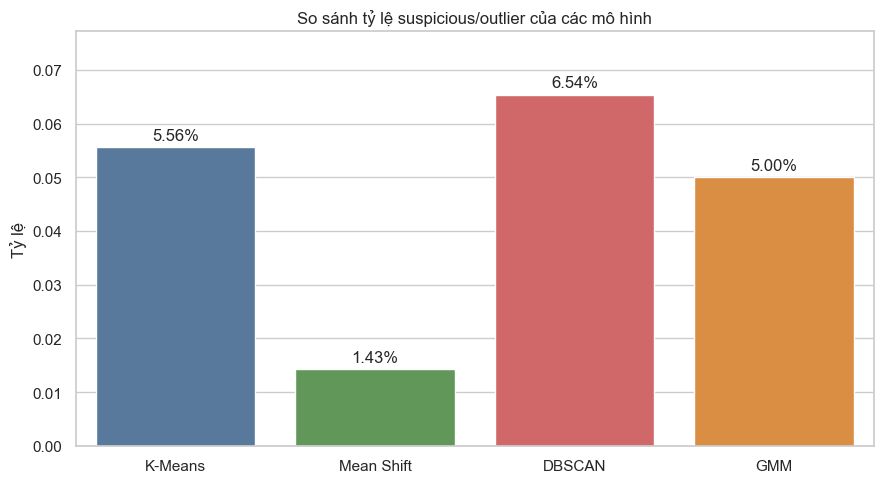

In [16]:
suspicious_ratio_df = pd.DataFrame({
    'Model': ['K-Means', 'Mean Shift', 'DBSCAN', 'GMM'],
    'Type': ['Suspicious cluster', 'Suspicious cluster', 'Outlier/noise', 'Low probability anomaly'],
    'Suspicious ratio': [
        sample_model['kmeans_suspicious'].mean(),
        sample_model['meanshift_suspicious'].mean(),
        sample_model['dbscan_suspicious'].mean(),
        sample_model['gmm_suspicious'].mean(),
    ],
})
display(suspicious_ratio_df)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=suspicious_ratio_df, x='Model', y='Suspicious ratio', palette=['#4C78A8', '#59A14F', '#E15759', '#F28E2B'])
ax.set_title('So sánh tỷ lệ suspicious/outlier của các mô hình')
ax.set_xlabel('')
ax.set_ylabel('Tỷ lệ')
ax.set_ylim(0, max(0.05, suspicious_ratio_df['Suspicious ratio'].max() * 1.18))
for patch, value in zip(ax.patches, suspicious_ratio_df['Suspicious ratio']):
    ax.annotate(f'{value:.2%}', (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_suspicious_ratio_comparison.png', dpi=150)
plt.show()

suspicious_ratio_df.to_csv(OUTPUT_DIR / 'model_suspicious_ratio_comparison.csv', index=False)

# 12. Model phụ 1 - Decision Tree

Decision Tree metrics: {'accuracy': 0.992, 'precision': 0.9159663865546218, 'recall': 0.9478260869565217, 'f1': 0.9316239316239316}
[[1875   10]
 [   6  109]]
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      1885
  Suspicious       0.92      0.95      0.93       115

    accuracy                           0.99      2000
   macro avg       0.96      0.97      0.96      2000
weighted avg       0.99      0.99      0.99      2000



,feature,importance
10,moveClampCount,0.860617
7,fireRateRejectCount,0.064844
6,invalidHitCount,0.047283
17,killsPerMinute,0.009454
9,maxMoveSpeedObserved,0.006432
16,invalidActionRate,0.004698
18,damagePerMinute,0.004286
13,pickupRejectCount,0.002387
1,weaponDamage,0.000000
0,survivedSeconds,0.000000


|--- moveClampCount <= 0.71
|   |--- fireRateRejectCount <= 1.32
|   |   |--- invalidHitCount <= 1.44
|   |   |   |--- damagePerMinute <= 7.47
|   |   |   |   |--- pickupRejectCount <= 2.66
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- pickupRejectCount >  2.66
|   |   |   |   |   |--- class: 1
|   |   |   |--- damagePerMinute >  7.47
|   |   |   |   |--- class: 1
|   |   |--- invalidHitCount >  1.44
|   |   |   |--- class: 1
|   |--- fireRateRejectCount >  1.32
|   |   |--- maxMoveSpeedObserved <= 1.17
|   |   |   |--- class: 1
|   |   |--- maxMoveSpeedObserved >  1.17
|   |   |   |--- class: 0
|--- moveClampCount >  0.71
|   |--- invalidHitCount <= 0.34
|   |   |--- moveClampCount <= 2.60
|   |   |   |--- killsPerMinute <= 1.90
|   |   |   |   |--- maxMoveSpeedObserved <= 1.84
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- maxMoveSpeedObserved >  1.84
|   |   |   |   |   |--- class: 1
|   |   |   |--- killsPerMinute >  1.90
|   |   |   |   |--- class: 1
|   |   |--- 

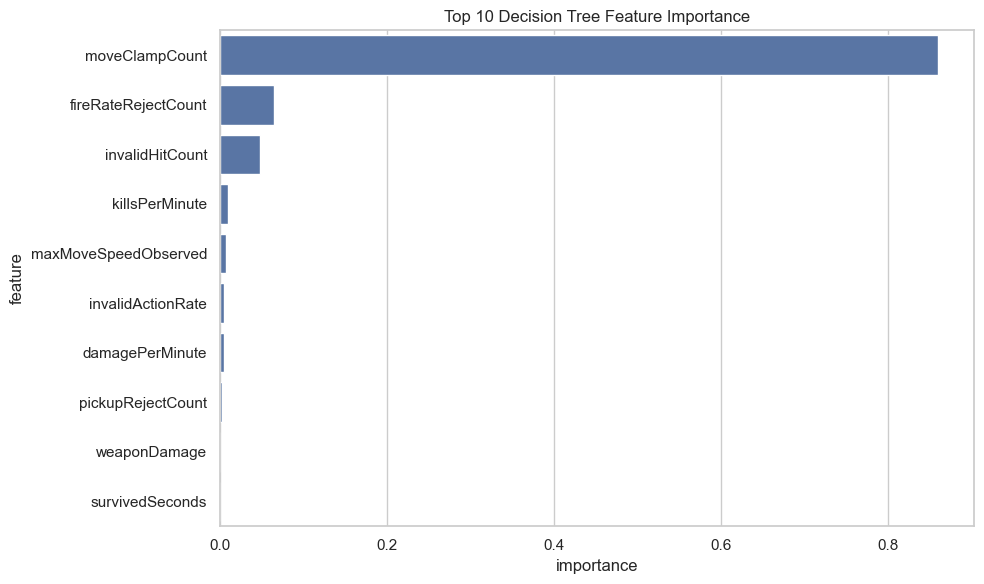

['D:\\Project\\Unity\\DACN1\\VectoArena_Server\\ml\\models\\vectoarena_decision_tree.pkl']

In [17]:
X_supervised = sample_model[feature_cols].copy()
y_supervised = sample_model['suspicious_label'].copy()
X_supervised_scaled = scaler.transform(X_supervised)

stratify_arg = y_supervised if y_supervised.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(X_supervised_scaled, y_supervised, test_size=0.2, random_state=RANDOM_STATE, stratify=stratify_arg)

decision_tree = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=RANDOM_STATE)
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)

dt_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'precision': precision_score(y_test, y_pred_dt, zero_division=0),
    'recall': recall_score(y_test, y_pred_dt, zero_division=0),
    'f1': f1_score(y_test, y_pred_dt, zero_division=0),
}

print('Decision Tree metrics:', dt_metrics)
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names=['Normal', 'Suspicious'], zero_division=0))

dt_importance = pd.DataFrame({'feature': feature_cols, 'importance': decision_tree.feature_importances_}).sort_values('importance', ascending=False)
display(dt_importance.head(20))

rules_text = export_text(decision_tree, feature_names=list(feature_cols), max_depth=5)
(REPORTS_DIR / 'decision_tree_rules.txt').write_text(rules_text, encoding='utf-8')
print(rules_text[:3000])

plt.figure(figsize=(10, 6))
sns.barplot(data=dt_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Decision Tree Feature Importance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'decision_tree_feature_importance.png', dpi=150)
plt.show()

joblib.dump(decision_tree, MODELS_DIR / 'vectoarena_decision_tree.pkl')

# 13. Model phụ 2 - Random Forest

Random Forest metrics: {'accuracy': 0.9955, 'precision': 0.9568965517241379, 'recall': 0.9652173913043478, 'f1': 0.961038961038961}
[[1880    5]
 [   4  111]]
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1885
  Suspicious       0.96      0.97      0.96       115

    accuracy                           1.00      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       1.00      1.00      1.00      2000



,feature,importance
16,invalidActionRate,0.176194
10,moveClampCount,0.169033
11,moveClampRate,0.142716
7,fireRateRejectCount,0.136927
6,invalidHitCount,0.099202
4,hitsAccepted,0.047809
5,hitRate,0.041647
13,pickupRejectCount,0.039218
19,damagePerKill,0.030478
15,meleeInvalidCount,0.026455


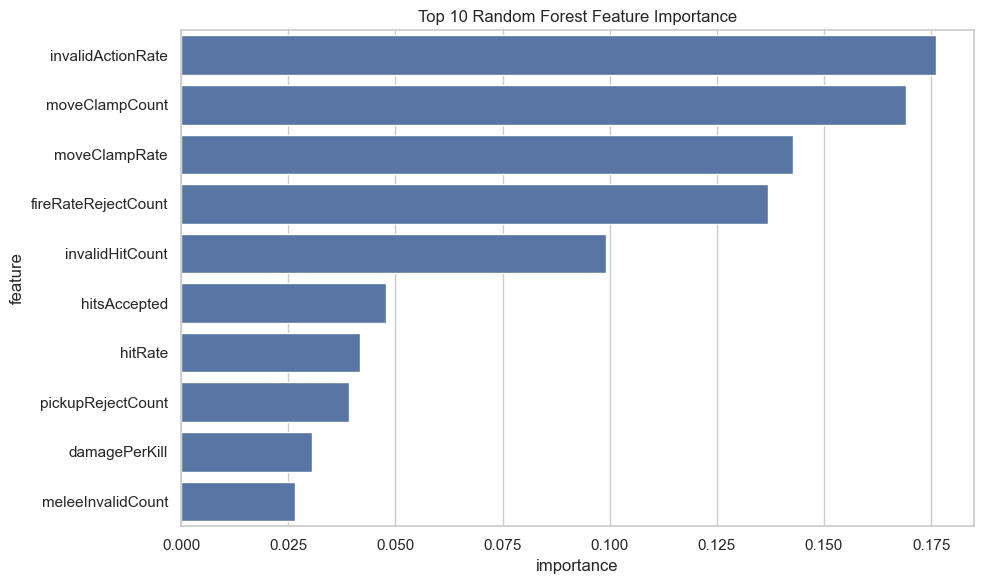

['D:\\Project\\Unity\\DACN1\\VectoArena_Server\\ml\\models\\vectoarena_random_forest.pkl']

In [18]:
random_forest = RandomForestClassifier(n_estimators=120, max_depth=10, min_samples_split=20, random_state=RANDOM_STATE, class_weight='balanced')
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)

rf_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'f1': f1_score(y_test, y_pred_rf, zero_division=0),
}

print('Random Forest metrics:', rf_metrics)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Suspicious'], zero_division=0))

rf_importance = pd.DataFrame({'feature': feature_cols, 'importance': random_forest.feature_importances_}).sort_values('importance', ascending=False)
display(rf_importance.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Random Forest Feature Importance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'random_forest_feature_importance.png', dpi=150)
plt.show()

joblib.dump(random_forest, MODELS_DIR / 'vectoarena_random_forest.pkl')

# 14. Dự đoán người chơi mới

In [19]:
def prepare_player_features(player_dict):
    player = pd.DataFrame([player_dict]).copy()
    derived_source_cols = [
        'shotsAccepted', 'hitsAccepted', 'totalDistance', 'survivedSeconds', 'kills', 'damageDealt',
        'invalidHitCount', 'fireRateRejectCount', 'pickupCount', 'pickupRejectCount',
        'meleeAttackCount', 'meleeInvalidCount'
    ]
    for col in sorted(set(feature_cols) | set(derived_source_cols)):
        if col not in player.columns:
            player[col] = 0

    if 'shotsAccepted' in player.columns and 'hitsAccepted' in player.columns:
        player['hitRate'] = np.where(player['shotsAccepted'] > 0, player['hitsAccepted'] / (player['shotsAccepted'] + EPSILON), 0)

    player['movementPerMinute'] = player['totalDistance'] / (player['survivedSeconds'] / 60 + EPSILON)
    player['killsPerMinute'] = player['kills'] / (player['survivedSeconds'] / 60 + EPSILON)
    player['damagePerMinute'] = player['damageDealt'] / (player['survivedSeconds'] / 60 + EPSILON)
    player['damagePerKill'] = np.where(player['kills'] > 0, player['damageDealt'] / (player['kills'] + EPSILON), 0)
    player['actionsRejected'] = player['invalidHitCount'] + player['fireRateRejectCount'] + player['pickupRejectCount'] + player['meleeInvalidCount']
    total_actions = player['shotsAccepted'] + player['pickupCount'] + player['meleeAttackCount'] + player['actionsRejected']
    player['invalidActionRate'] = np.where(total_actions > 0, player['actionsRejected'] / (total_actions + EPSILON), 0)

    for col in feature_cols:
        if col.startswith('mode_') or col.startswith('primaryWeapon_'):
            player[col] = 0

    mode_col = 'mode_' + str(player_dict.get('mode', 'BATTLE'))
    if mode_col in player.columns:
        player[mode_col] = 1

    weapon_col = 'primaryWeapon_' + str(player_dict.get('primaryWeapon', 'Rifle'))
    if weapon_col in player.columns:
        player[weapon_col] = 1

    return player[feature_cols].replace([np.inf, -np.inf], 0).fillna(0)

def predict_new_player(player_dict):
    player_features = prepare_player_features(player_dict)
    player_scaled = scaler.transform(player_features)
    pred = int(random_forest.predict(player_scaled)[0])
    proba = random_forest.predict_proba(player_scaled)[0]
    suspicious_score = float(proba[list(random_forest.classes_).index(1)]) if 1 in random_forest.classes_ else float(pred)
    return {'result': 'Suspicious' if pred == 1 else 'Normal', 'suspicious_score': suspicious_score, 'feature_values': player_features.iloc[0].to_dict()}

normal_player = {
    'mode': 'BATTLE', 'maxPlayers': 4, 'matchDurationSeconds': 220, 'survivedSeconds': 180,
    'placement': 2, 'isWinner': 0, 'primaryWeapon': 'Rifle', 'weaponDamage': 10,
    'weaponFireRatePerSecond': 10, 'kills': 1, 'deaths': 1, 'damageDealt': 120,
    'damageTaken': 80, 'shotsAccepted': 28, 'hitsAccepted': 7, 'invalidHitCount': 0,
    'fireRateRejectCount': 0, 'totalDistance': 420, 'maxMoveSpeedObserved': 3.2,
    'moveClampCount': 0, 'moveClampRate': 0, 'pickupCount': 5, 'pickupRejectCount': 0,
    'vecCollected': 0, 'vecDropped': 0, 'meleeAttackCount': 2, 'meleeInvalidCount': 0,
    'allowedMaxHitDistance': 60, 'allowedMaxItemPickupDistance': 3, 'allowedMoveSpeedWithGrace': 4.725,
}

suspicious_player = {
    'mode': 'BATTLE', 'maxPlayers': 4, 'matchDurationSeconds': 210, 'survivedSeconds': 190,
    'placement': 1, 'isWinner': 1, 'primaryWeapon': 'Sniper', 'weaponDamage': 50,
    'weaponFireRatePerSecond': 0.8, 'kills': 14, 'deaths': 0, 'damageDealt': 1450,
    'damageTaken': 20, 'shotsAccepted': 18, 'hitsAccepted': 17, 'invalidHitCount': 12,
    'fireRateRejectCount': 8, 'totalDistance': 90, 'maxMoveSpeedObserved': 8.5,
    'moveClampCount': 14, 'moveClampRate': 0.25, 'pickupCount': 2, 'pickupRejectCount': 4,
    'vecCollected': 0, 'vecDropped': 0, 'meleeAttackCount': 0, 'meleeInvalidCount': 1,
    'allowedMaxHitDistance': 60, 'allowedMaxItemPickupDistance': 3, 'allowedMoveSpeedWithGrace': 4.725,
}

print('Kết quả người chơi bình thường:')
display(predict_new_player(normal_player))

print('Kết quả người chơi đáng nghi:')
display(predict_new_player(suspicious_player))

Kết quả người chơi bình thường:


{'result': 'Normal',
 'suspicious_score': 0.007742863010885193,
 'feature_values': {'survivedSeconds': 180.0,
  'weaponDamage': 10.0,
  'weaponFireRatePerSecond': 10.0,
  'shotsAccepted': 28.0,
  'hitsAccepted': 7.0,
  'hitRate': 0.24999999107142887,
  'invalidHitCount': 0.0,
  'fireRateRejectCount': 0.0,
  'movementPerMinute': 139.99995333334888,
  'maxMoveSpeedObserved': 3.2,
  'moveClampCount': 0.0,
  'moveClampRate': 0.0,
  'pickupCount': 5.0,
  'pickupRejectCount': 0.0,
  'meleeAttackCount': 2.0,
  'meleeInvalidCount': 0.0,
  'invalidActionRate': 0.0,
  'killsPerMinute': 0.33333322222225925,
  'damagePerMinute': 39.999986666671106,
  'damagePerKill': 119.99988000012002,
  'mode_BATTLE': 1.0,
  'mode_PLAY_TO_AIRDROP': 0.0,
  'primaryWeapon_BlasterShotgun': 0.0,
  'primaryWeapon_BurstRifle': 0.0,
  'primaryWeapon_HunterSniper': 0.0,
  'primaryWeapon_Launcher': 0.0,
  'primaryWeapon_MachineGun': 0.0,
  'primaryWeapon_Minigun': 0.0,
  'primaryWeapon_Pistol': 0.0,
  'primaryWeapon_Rebe

Kết quả người chơi đáng nghi:


{'result': 'Suspicious',
 'suspicious_score': 0.9998980019662421,
 'feature_values': {'survivedSeconds': 190.0,
  'weaponDamage': 50.0,
  'weaponFireRatePerSecond': 0.8,
  'shotsAccepted': 18.0,
  'hitsAccepted': 17.0,
  'hitRate': 0.9444443919753115,
  'invalidHitCount': 12.0,
  'fireRateRejectCount': 8.0,
  'movementPerMinute': 28.42104365651253,
  'maxMoveSpeedObserved': 8.5,
  'moveClampCount': 14.0,
  'moveClampRate': 0.25,
  'pickupCount': 2.0,
  'pickupRejectCount': 4.0,
  'meleeAttackCount': 0.0,
  'meleeInvalidCount': 1.0,
  'invalidActionRate': 0.5555555432098769,
  'killsPerMinute': 4.4210512354575044,
  'damagePerMinute': 457.89459224381295,
  'damagePerKill': 103.57142117346991,
  'mode_BATTLE': 1.0,
  'mode_PLAY_TO_AIRDROP': 0.0,
  'primaryWeapon_BlasterShotgun': 0.0,
  'primaryWeapon_BurstRifle': 0.0,
  'primaryWeapon_HunterSniper': 0.0,
  'primaryWeapon_Launcher': 0.0,
  'primaryWeapon_MachineGun': 0.0,
  'primaryWeapon_Minigun': 0.0,
  'primaryWeapon_Pistol': 0.0,
  'p

# 15. Tổng hợp kết quả

In [20]:
summary_rows = [
    {'Mô hình': 'K-Means', 'Vai trò': 'Gom nhóm hành vi', 'Metric/Kết quả chính': f'K = {best_k}, silhouette = {np.nanmax(silhouette_scores):.4f}', 'Nhận xét': f'Tỷ lệ suspicious = {sample_model["kmeans_suspicious"].mean():.4f}'},
    {'Mô hình': 'Mean Shift', 'Vai trò': 'Gom cụm không cần chọn số cụm', 'Metric/Kết quả chính': f'Số cụm = {n_ms_clusters}', 'Nhận xét': f'Tỷ lệ suspicious = {sample_model["meanshift_suspicious"].mean():.4f}'},
    {'Mô hình': 'DBSCAN', 'Vai trò': 'Phát hiện outlier theo mật độ', 'Metric/Kết quả chính': f'eps = {chosen_eps}, outlier ratio = {sample_model["dbscan_suspicious"].mean():.4f}', 'Nhận xét': 'Noise -1 được xem là suspicious/outlier.'},
    {'Mô hình': 'GMM', 'Vai trò': 'Phát hiện điểm xác suất thấp', 'Metric/Kết quả chính': f'n_components = {best_n_components}, threshold = {gmm_threshold:.4f}', 'Nhận xét': f'Tỷ lệ suspicious = {sample_model["gmm_suspicious"].mean():.4f}'},
    {'Mô hình': 'Decision Tree', 'Vai trò': 'Giải thích pseudo-label', 'Metric/Kết quả chính': ', '.join([f'{k} = {v:.4f}' for k, v in dt_metrics.items()]), 'Nhận xét': 'Metric chỉ đánh giá khả năng học pseudo-label.'},
    {'Mô hình': 'Random Forest', 'Vai trò': 'Dự đoán nhanh người chơi mới', 'Metric/Kết quả chính': ', '.join([f'{k} = {v:.4f}' for k, v in rf_metrics.items()]), 'Nhận xét': 'Có thể dùng cho scoring sau trận.'},
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(OUTPUT_DIR / 'model_summary.csv', index=False, encoding='utf-8-sig')

sample_model.to_csv(OUTPUT_DIR / 'vectoarena_pseudo_labeled.csv', index=False)
print('Đã lưu outputs và models.')

,Mô hình,Vai trò,Metric/Kết quả chính,Nhận xét
0,K-Means,Gom nhóm hành vi,"K = 2, silhouette = 0.4492",Tỷ lệ suspicious = 0.0556
1,Mean Shift,Gom cụm không cần chọn số cụm,Số cụm = 4,Tỷ lệ suspicious = 0.0143
2,DBSCAN,Phát hiện outlier theo mật độ,"eps = 3.5, outlier ratio = 0.0654",Noise -1 được xem là suspicious/outlier.
3,GMM,Phát hiện điểm xác suất thấp,"n_components = 10, threshold = -24.7622",Tỷ lệ suspicious = 0.0500
4,Decision Tree,Giải thích pseudo-label,"accuracy = 0.9920, precision = 0.9160, recall ...",Metric chỉ đánh giá khả năng học pseudo-label.
5,Random Forest,Dự đoán nhanh người chơi mới,"accuracy = 0.9955, precision = 0.9569, recall ...",Có thể dùng cho scoring sau trận.


Đã lưu outputs và models.


# 16. Kết luận

Notebook đã xây dựng pipeline phát hiện hành vi đáng nghi trong VectoArena bằng học không giám sát:

- **K-Means** gom nhóm hành vi.
- **Mean Shift** gom cụm không cần chọn trước số cụm.
- **DBSCAN** phát hiện outlier theo mật độ.
- **GMM** phát hiện anomaly dựa trên xác suất thấp.
- **Decision Tree/Random Forest** học lại pseudo-label để giải thích và dự đoán nhanh.

Vì dataset hiện tại là synthetic và chưa có nhãn cheater thật, kết quả chỉ nên dùng để demo, kiểm thử pipeline và làm baseline ban đầu. Khi game có telemetry thật, cần retrain và review thủ công các case suspicious trước khi dùng cho enforcement.